
This Jupyter notebook is a template with a header and footer.

In the header, it is included:
- Title : MAM2ADMM project
- Author : Anaïs RAGON and Co pilot 
- Date : 09/03/2027





# Presentation of my project 
XXXXX



In [1]:
import pandas as pd
import numpy as np
from io import StringIO

# ---------- STEP 1: READ FILE ----------
with open("data/Data_droite.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

# ---------- STEP 2: FIND BLOCKS ----------
idx_push = None
idx_move = None
for i, line in enumerate(lines):
    if "K-Push" in line:
        idx_push = i
    if "K-Move" in line and idx_move is None:
        idx_move = i

# ---------- STEP 3: SPLIT BLOCKS ----------
push_lines = lines[idx_push:idx_move] if idx_push < idx_move else lines[idx_push:]
move_lines = lines[idx_move:] if idx_push < idx_move else lines[idx_move:idx_push]

# ---------- STEP 4: CLEAN K-PUSH ----------
header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)
push_str = "".join(push_lines[header_idx_push:])
df_push = pd.read_csv(StringIO(push_str), sep=r"\t|,", engine="python", on_bad_lines="skip")
df_push = df_push.dropna(axis=1, how='all')
df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
df_push = df_push[["time", "force"]]
df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

# ---------- STEP 5: CLEAN K-MOVE ----------
# Extract baseline quaternions
baseline = {}
for line in move_lines:
    if "Quaternion de base" in line:
        parts = line.strip().split("\t")
        sensor = parts[0]
        values = [float(x) for x in parts[1:5]]
        if "S121577" in sensor:
            baseline["wrist"] = values
        elif "S121578" in sensor:
            baseline["shoulder"] = values

# Find header line
header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

# Get data lines after header
move_data_lines = move_lines[header_idx_move + 1:]

# Split each line by tab first; if tabs missing, fallback to comma
split_rows = []
for line in move_data_lines:
    row = line.strip().split("\t")
    if len(row) < 2:
        row = line.strip().split(",")
    split_rows.append(row)

# Convert to DataFrame
df_move = pd.DataFrame(split_rows)

# Drop empty columns
df_move = df_move.dropna(axis=1, how='all')

# Convert to numeric
df_move = df_move.apply(pd.to_numeric, errors='coerce')
df_move = df_move.ffill().bfill()

# ---------- STEP 6: ASSIGN COLUMNS BY YOUR SPEC ----------
# S121577 wrist → columns B,C,D,E → indices 1,2,3,4
df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
df_wrist.columns = ["time","qx","qy","qz","qw"]

# S121578 shoulder → columns G,H,I,J → indices 6,7,8,9 (+0 for time in column 0)
df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
df_shoulder.columns = ["time","qx","qy","qz","qw"]

# ---------- STEP 7: FINAL CHECK ----------
print("K-Push:\n", df_push.head())
print("\nWrist (S121577):\n", df_wrist.head())
print("\nShoulder (S121578):\n", df_shoulder.head())
print("\nBaseline wrist:", baseline["wrist"])
print("Baseline shoulder:", baseline["shoulder"])
print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)


K-Push:
     time   force
0  0.000  0.3391
1  0.002  0.3241
2  0.004  0.3271
3  0.006  0.3260
4  0.008  0.2902

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.180603 -0.564087 -0.615723  0.519531
1  0.008  0.180578 -0.564136 -0.615774  0.519518
2  0.016  0.180548 -0.564166 -0.615834  0.519426
3  0.024  0.180547 -0.564194 -0.615922  0.519301
4  0.032  0.180516 -0.564223 -0.616013  0.519178

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.662598  0.119934 -0.083679  0.734497
1  0.008 -0.662614  0.119937 -0.083651  0.734515
2  0.016 -0.662615  0.119937 -0.083620  0.734516
3  0.024 -0.662615  0.119937 -0.083590  0.734517
4  0.032 -0.662616  0.119937 -0.083559  0.734518

Baseline wrist: []
Baseline shoulder: []

Shapes: (20840, 2) (5205, 5) (5205, 5)


In [2]:
# ---------- STEP 2: SIMPLIFIED BASELINE EXTRACTION ----------
baseline_kmove = {}

# Loop through move_lines until the header line
for line in move_lines:
    if "Quaternion de base" in line:
        parts = line.strip().split("\t")  # split by tab
        sensor_name = parts[0]            # e.g. "K-Move (S121577) Quaternion de base (x-y-z-w)"
        values = [float(x) for x in parts[1:5]]  # take the next 4 numeric values
        if "S121577" in sensor_name:
            baseline_kmove["wrist"] = values
        elif "S121578" in sensor_name:
            baseline_kmove["shoulder"] = values

# ---------- CHECK ----------
print("Baseline wrist (S121577):", baseline_kmove.get("wrist"))
print("Baseline shoulder (S121578):", baseline_kmove.get("shoulder"))

Baseline wrist (S121577): []
Baseline shoulder (S121578): []


In [3]:
from scipy.signal import butter, filtfilt

# ---------- STEP 3: LOW-PASS BUTTERWORTH FILTER ----------
def lowpass_filter(signal, cutoff=10, fs=125, order=4):
    """
    Apply a low-pass Butterworth filter to a 1D signal.
    
    Parameters:
        signal: 1D array or list
        cutoff: cutoff frequency in Hz (default 10)
        fs: sampling frequency in Hz (default 125)
        order: filter order (default 4)
        
    Returns:
        filtered_signal: 1D numpy array
    """
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Apply filter to wrist angles (or quaternion components if needed)
df_wrist_filtered = df_wrist.copy()
df_shoulder_filtered = df_shoulder.copy()

for col in ["qx", "qy", "qz", "qw"]:
    df_wrist_filtered[col] = lowpass_filter(df_wrist[col], cutoff=10, fs=125)
    df_shoulder_filtered[col] = lowpass_filter(df_shoulder[col], cutoff=10, fs=125)

# ---------- STEP 3 CHECK ----------
print("Filtered wrist (first 5 rows):\n", df_wrist_filtered.head())
print("\nFiltered shoulder (first 5 rows):\n", df_shoulder_filtered.head())

Filtered wrist (first 5 rows):
     time        qx        qy        qz        qw
0  0.000  0.180603 -0.564087 -0.615722  0.519532
1  0.008  0.180563 -0.564133 -0.615789  0.519445
2  0.016  0.180524 -0.564176 -0.615858  0.519357
3  0.024  0.180486 -0.564209 -0.615931  0.519267
4  0.032  0.180451 -0.564231 -0.616009  0.519177

Filtered shoulder (first 5 rows):
     time        qx        qy        qz        qw
0  0.000 -0.662598  0.119935 -0.083680  0.734496
1  0.008 -0.662608  0.119934 -0.083640  0.734500
2  0.016 -0.662616  0.119932 -0.083603  0.734505
3  0.024 -0.662620  0.119929 -0.083572  0.734512
4  0.032 -0.662618  0.119926 -0.083548  0.734522


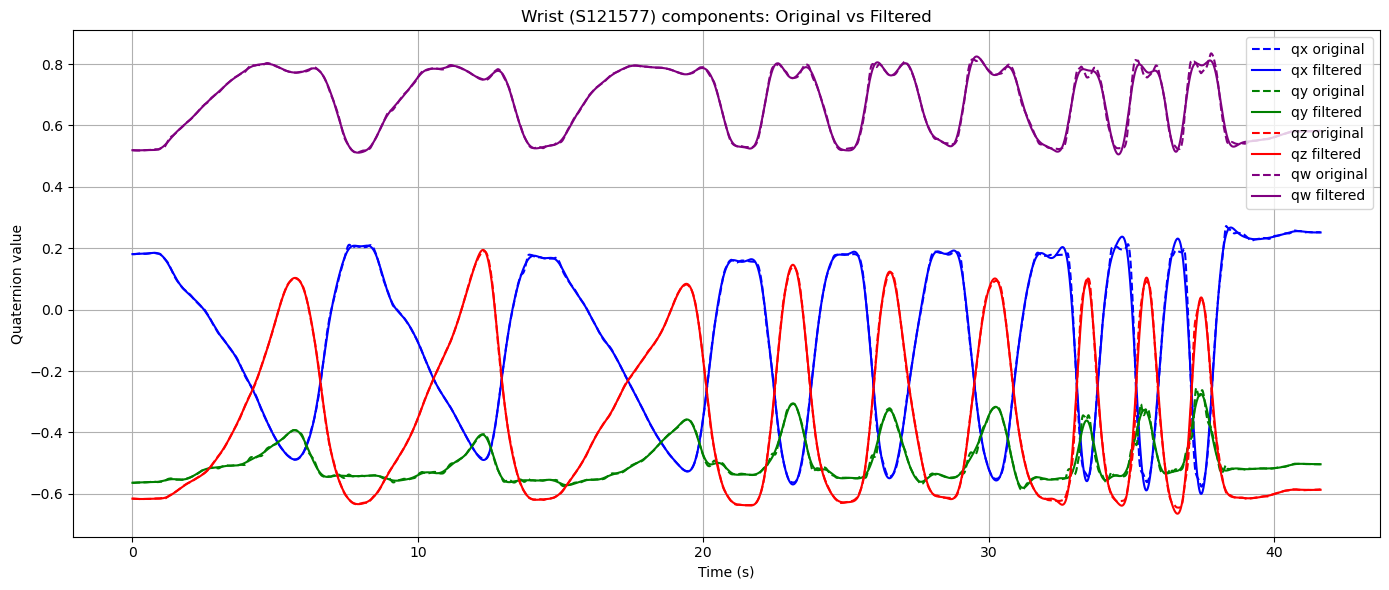

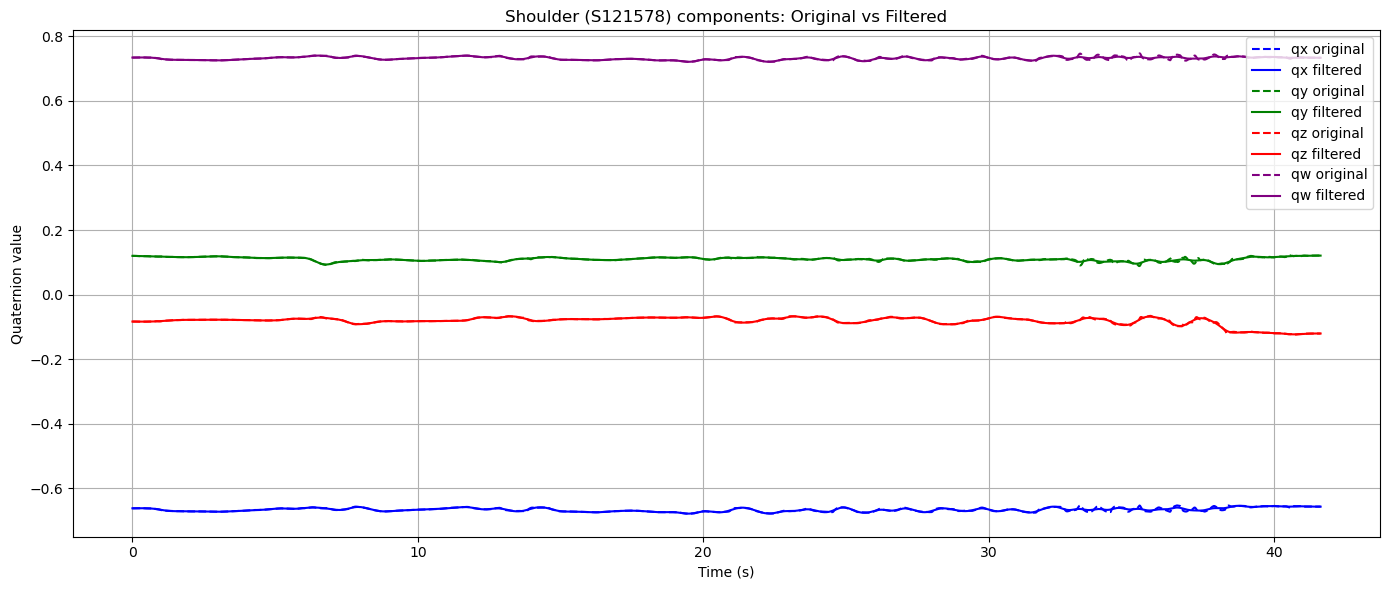

In [4]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# ---------- FUNCTION: LOW-PASS BUTTERWORTH FILTER ----------
def butter_lowpass_filter(df, components=["qx","qy","qz","qw"], cutoff=10, fs=1000, order=4):
    """
    Apply low-pass Butterworth filter to selected components.
    
    Parameters:
        df : DataFrame with time column and components
        components : list of component column names
        cutoff : cutoff frequency in Hz
        fs : sampling frequency in Hz
        order : order of the filter
    Returns:
        df_filtered : new DataFrame with filtered signals
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    df_filtered = df.copy()
    for col in components:
        df_filtered[col] = filtfilt(b, a, df[col])
    return df_filtered

# ---------- FUNCTION: PLOT ALL COMPONENTS ----------
def plot_all_components(df_original, df_filtered, sensor_name="Sensor"):
    """
    Plot all 4 components (qx,qy,qz,qw) on the same figure,
    comparing original vs filtered.
    """
    components = ["qx","qy","qz","qw"]
    colors = ["blue", "green", "red", "purple"]
    
    plt.figure(figsize=(14,6))
    for i, col in enumerate(components):
        plt.plot(df_original["time"], df_original[col], color=colors[i], linestyle='--', label=f"{col} original")
        plt.plot(df_filtered["time"], df_filtered[col], color=colors[i], linestyle='-', label=f"{col} filtered")
    
    plt.title(f"{sensor_name} components: Original vs Filtered")
    plt.xlabel("Time (s)")
    plt.ylabel("Quaternion value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------- EXAMPLE USAGE ----------
# Keep original data intact
df_wrist_original = df_wrist.copy()
df_shoulder_original = df_shoulder.copy()

# Filter the signals
df_wrist_filtered = butter_lowpass_filter(df_wrist_original, cutoff=10, fs=1000, order=4)
df_shoulder_filtered = butter_lowpass_filter(df_shoulder_original, cutoff=10, fs=1000, order=4)

# Plot both sensors
plot_all_components(df_wrist_original, df_wrist_filtered, sensor_name="Wrist (S121577)")
plot_all_components(df_shoulder_original, df_shoulder_filtered, sensor_name="Shoulder (S121578)")

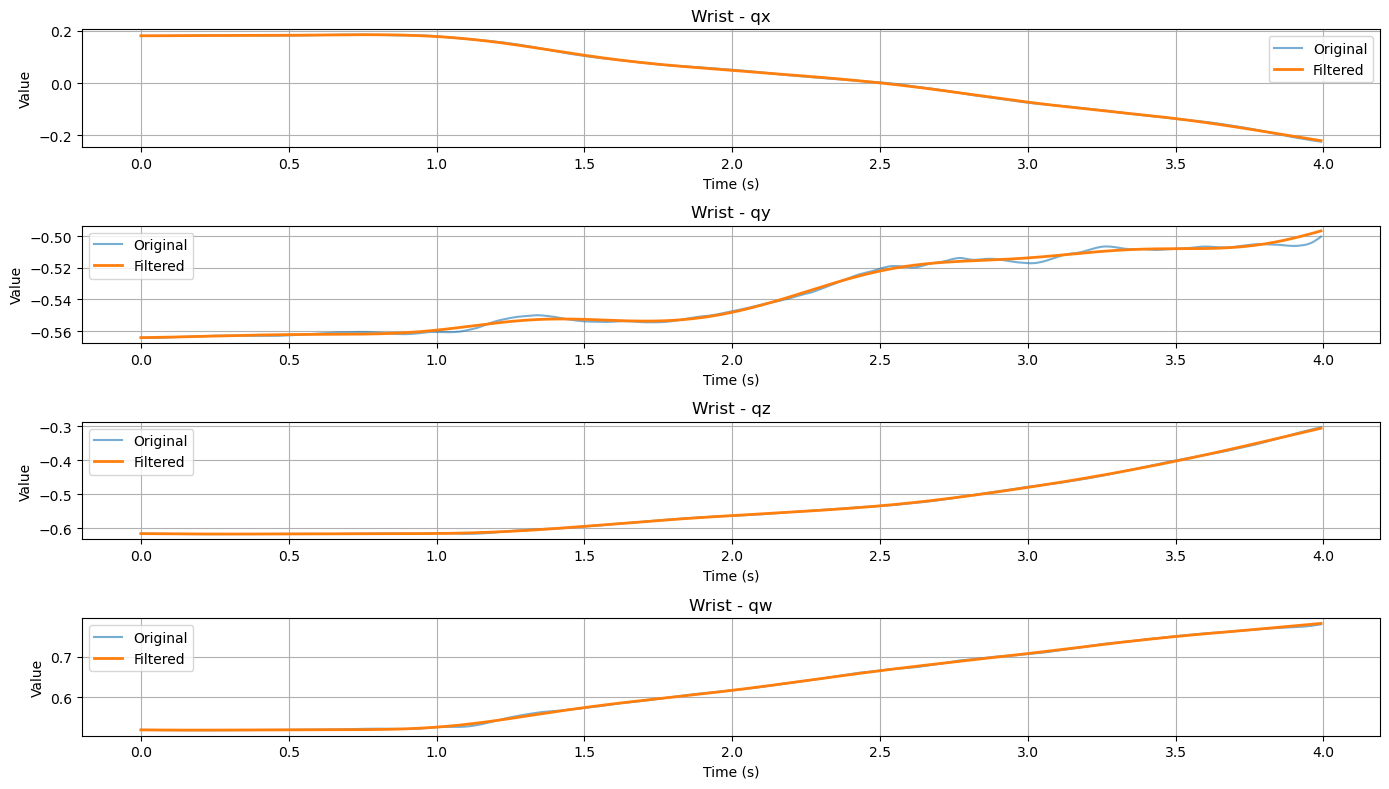

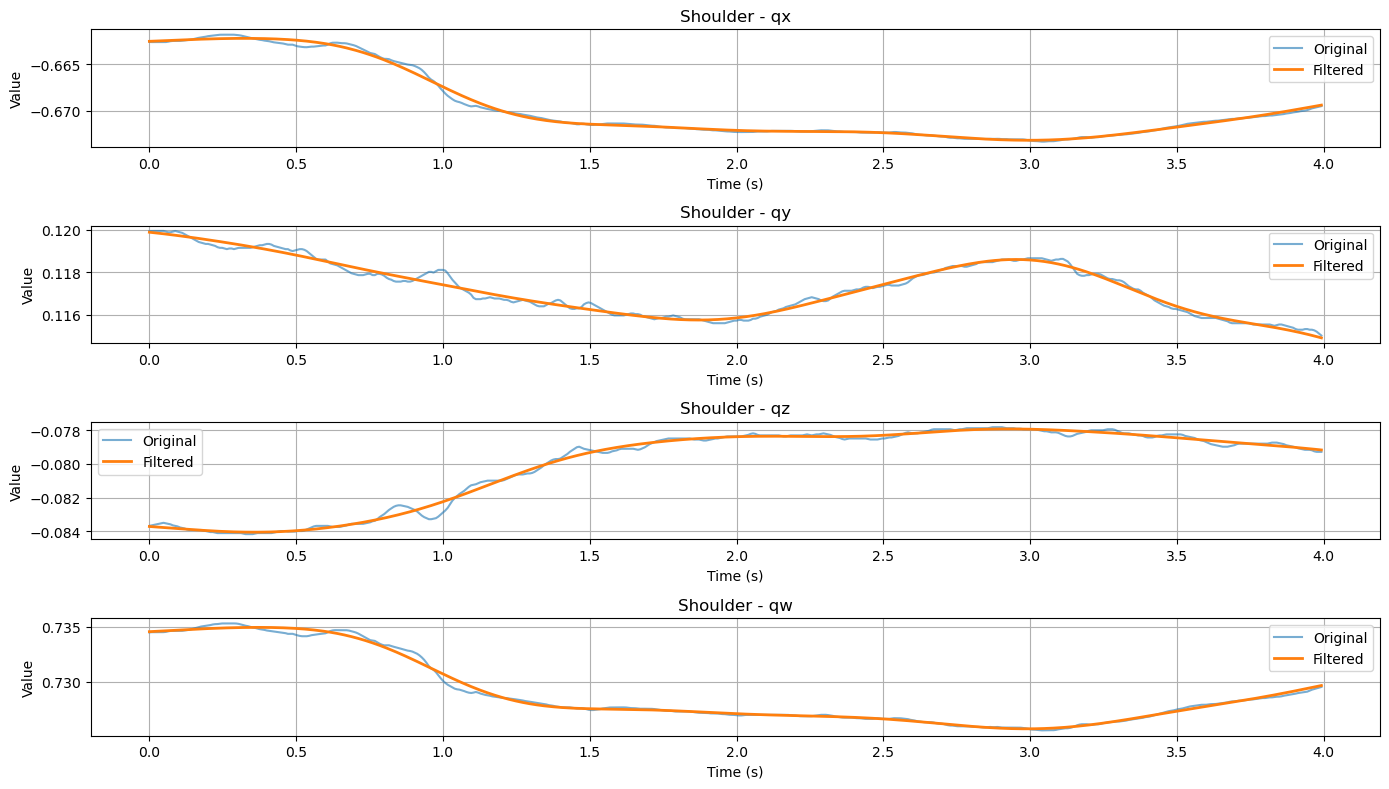

In [5]:
import matplotlib.pyplot as plt

def plot_filtered_vs_original(df_original, df_filtered, sensor_name="Wrist", components=["qx","qy","qz","qw"], n_samples=500):
    """
    Plot original vs filtered signals for given quaternion components.
    
    Parameters:
        df_original: DataFrame with original signals
        df_filtered: DataFrame with filtered signals
        sensor_name: string, e.g., "Wrist" or "Shoulder"
        components: list of columns to plot
        n_samples: number of samples to plot (for clarity)
    """
    time = df_original["time"].iloc[:n_samples]

    plt.figure(figsize=(14, 8))
    for i, col in enumerate(components):
        plt.subplot(len(components), 1, i+1)
        plt.plot(time, df_original[col].iloc[:n_samples], label="Original", alpha=0.6)
        plt.plot(time, df_filtered[col].iloc[:n_samples], label="Filtered", linewidth=2)
        plt.title(f"{sensor_name} - {col}")
        plt.xlabel("Time (s)")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()


# ---------- EXAMPLE USAGE ----------
# Wrist plot
plot_filtered_vs_original(df_wrist, df_wrist_filtered, sensor_name="Wrist")

# Shoulder plot
plot_filtered_vs_original(df_shoulder, df_shoulder_filtered, sensor_name="Shoulder")

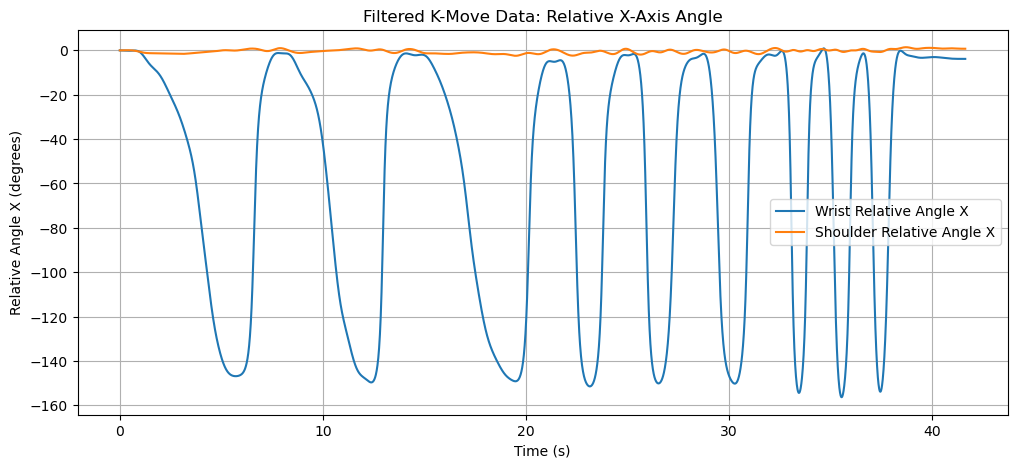

Wrist baseline angle X (deg): 71.33460071509394
Shoulder baseline angle X (deg): -84.6309943772851


In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt

# ---------- STEP 4:  FUNCTION: CONVERT QUATERNION TO X-AXIS ANGLE ----------
#def quaternion_to_angle_x(df_quat, baseline=None):
    """
    Convert filtered quaternions to rotation angle around the X-axis.

    Parameters:
        df_quat : pandas DataFrame with columns ['time', 'qx','qy','qz','qw']
                  representing the filtered quaternion signal.
        baseline : float, reference angle in degrees (optional). If None, first value is used.

    Returns:
        df_angles : DataFrame with columns ['time', 'angle_x', 'angle_x_relative']
        baseline : float, baseline angle used for relative computation
    """
    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values
    
    # Convert quaternion to X-axis rotation angle (roll)
    # Formula: roll = atan2(2*(w*x + y*z), 1 - 2*(x^2 + y^2))
    #angle_x = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    
    # Convert radians to degrees
   # angle_x_deg = np.degrees(angle_x)
    
    # Determine baseline if not provided
    #if baseline is None:
        baseline = angle_x_deg[0]  # first point as reference
    
    # Compute relative angle from baseline
   # angle_x_relative = angle_x_deg - baseline
    
    # Store results in DataFrame
   # df_angles = df_quat[["time"]].copy()
   # df_angles["angle_x"] = angle_x_deg
   # df_angles["angle_x_relative"] = angle_x_relative
    
   # return df_angles, baseline

# ---------- EXAMPLE USAGE WITH FILTERED DATA ----------
# Apply function to wrist sensor
df_wrist_angles, wrist_baseline = quaternion_to_angle_x(df_wrist_filtered)

# Apply function to shoulder sensor
df_shoulder_angles, shoulder_baseline = quaternion_to_angle_x(df_shoulder_filtered)

# ---------- PLOT RELATIVE ANGLES ----------
plt.figure(figsize=(12,5))
plt.plot(df_wrist_angles["time"], df_wrist_angles["angle_x_relative"], label="Wrist Relative Angle X")
plt.plot(df_shoulder_angles["time"], df_shoulder_angles["angle_x_relative"], label="Shoulder Relative Angle X")
plt.xlabel("Time (s)")
plt.ylabel("Relative Angle X (degrees)")
plt.title("Filtered K-Move Data: Relative X-Axis Angle")
plt.legend()
plt.grid(True)
plt.show()

# ---------- PRINT BASELINES ----------
print("Wrist baseline angle X (deg):", wrist_baseline)
print("Shoulder baseline angle X (deg):", shoulder_baseline)

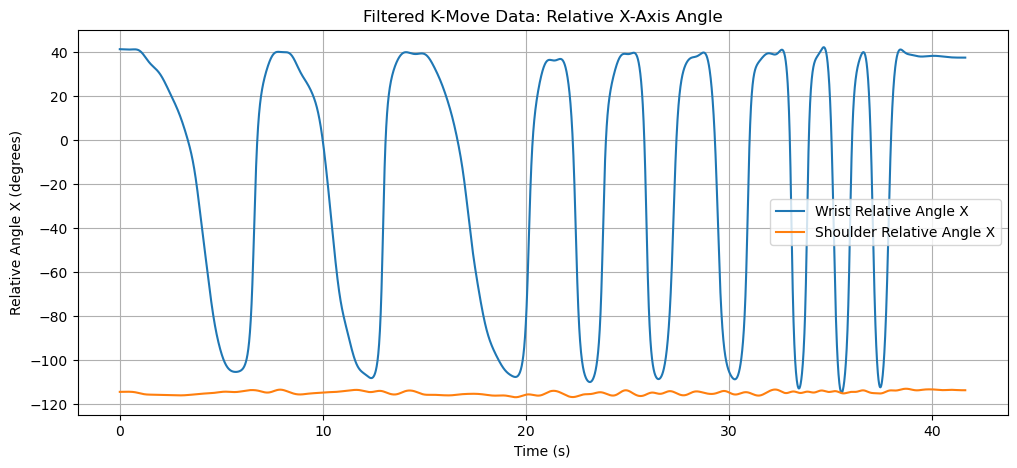

Wrist baseline angle X (deg): 30
Shoulder baseline angle X (deg): 30


In [166]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- MANUAL CALIBRATION (TO FILL) ----------
# Enter here the reference angle measured from video (Kinovea) at the maximum of the flexion movement for each sensor. This will be used as the baseline to compute relative angles.
manual_baseline_angle = 30  # <-- replace with your value (e.g., 65) or set to None for automatic baseline

# 

#with this version, if we put manue_baseline_angle = XX (it's with video calibration) 
# If put None →  automatic behavior (first point as baseline)

# ---------- FUNCTION: CONVERT QUATERNION TO X-AXIS ANGLE ----------
def quaternion_to_angle_x(df_quat, baseline=None):
    """
    Convert filtered quaternions to rotation angle around the X-axis.

    Parameters:
        df_quat : pandas DataFrame with columns ['time', 'qx','qy','qz','qw']
        baseline : float, reference angle in degrees (optional)

    Returns:
        df_angles : DataFrame with columns ['time', 'angle_x', 'angle_x_relative']
        baseline : float, baseline angle used
    """
    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values
    
    # Convert quaternion to X-axis rotation angle (roll)
    angle_x = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    
    # Convert radians to degrees
    angle_x_deg = np.degrees(angle_x)
    
    # ---------- BASELINE HANDLING ----------
    if baseline is not None:
        # Use manual calibration (from video)
        angle_x_relative = angle_x_deg - manual_baseline_angle
    else:
        # Default: first point
        baseline = angle_x_deg[0]
        angle_x_relative = angle_x_deg - baseline
    
    # Store results
    df_angles = df_quat[["time"]].copy()
    df_angles["angle_x"] = angle_x_deg
    df_angles["angle_x_relative"] = angle_x_relative
    
    return df_angles, baseline

# ---------- EXAMPLE USAGE WITH FILTERED DATA ----------
# Wrist
df_wrist_angles, wrist_baseline = quaternion_to_angle_x(
    df_wrist_filtered,
    baseline=manual_baseline_angle
)

# Shoulder
df_shoulder_angles, shoulder_baseline = quaternion_to_angle_x(
    df_shoulder_filtered,
    baseline=manual_baseline_angle
)

# ---------- PLOT ----------
plt.figure(figsize=(12,5))
plt.plot(df_wrist_angles["time"], df_wrist_angles["angle_x_relative"], label="Wrist Relative Angle X")
plt.plot(df_shoulder_angles["time"], df_shoulder_angles["angle_x_relative"], label="Shoulder Relative Angle X")
plt.xlabel("Time (s)")
plt.ylabel("Relative Angle X (degrees)")
plt.title("Filtered K-Move Data: Relative X-Axis Angle")
plt.legend()
plt.grid(True)
plt.show()

# ---------- PRINT ----------
print("Wrist baseline angle X (deg):", wrist_baseline)
print("Shoulder baseline angle X (deg):", shoulder_baseline)



### je fais une pause ici car l'application tracker (car kinovea ne fonctionne par sur mac) est bloqué sur le réseau wifi du chu je reprendre à cette étape plus tard pour faire la calibration vidéo et comparer les résultats.

In [167]:
from scipy.signal import find_peaks
# -------- STEP 5: DETECT MAXIMA AND MINIMA IN THE RELATIVE ANGLE SIGNAL---------
# Extract signal
signal = df_wrist_angles["angle_x_relative"].values
time = df_wrist_angles["time"].values

# ---------- DETECT MAXIMA ----------
peaks_max, _ = find_peaks(
    signal,
    distance=200,      # minimum distance between peaks (adjust if needed)
)

# ---------- DETECT MINIMA ----------
peaks_min, _ = find_peaks(
    -signal,
    distance=200,
)
#extraire les valeurs des minimums à partir des indices
peaks_min_values = signal[peaks_min]
peaks_min_values_tries = np.argsort(peaks_min_values)

# selectionner les indices des 9 minima les plus faibles 
minima = np.sort(peaks_min[peaks_min_values_tries[:9]]) 






# ---------- FIX: include first peak if missed ----------
if signal[0] > signal[1]:
    peaks_max = np.insert(peaks_max, 0, 0)


print("peaks_min:", minima)








peaks_min: [ 713 1548 2435 2893 3316 3786 4180 4443 4681]


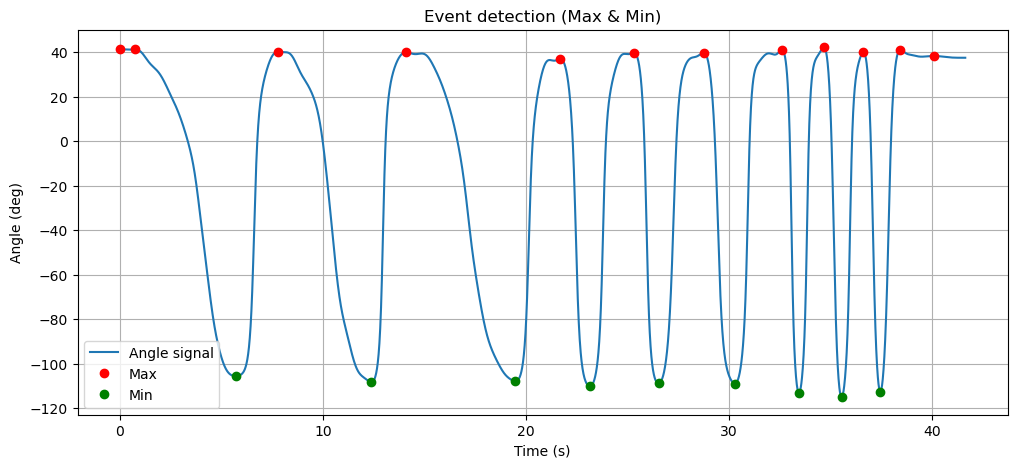

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(time, signal, label="Angle signal")

# Plot maxima
plt.plot(time[peaks_max], signal[peaks_max], "ro", label="Max")

# Plot minima
plt.plot(time[minima], signal[minima], "go", label="Min")

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Event detection (Max & Min)")
plt.legend()
plt.grid(True)
plt.show()



In [169]:
# Keep only first 9 max and min
peaks_max = peaks_max[:9]
peaks_min = peaks_min[:9]

# Create labels
labels = ["slow"]*3 + ["medium"]*3 + ["fast"]*3

events = []

for i in range(9):
    events.append({
        "index_max": peaks_max[i],
        "time_max": time[peaks_max[i]],
        "angle_max": signal[peaks_max[i]],
        "speed": labels[i]
    })

# Convert to DataFrame
import pandas as pd
df_events = pd.DataFrame(events)

print(df_events)

   index_max  time_max  angle_max   speed
0          0    0.0000  41.334601    slow
1         91    0.7280  41.267008    slow
2        975    7.8000  40.143022    slow
3       1762   14.0960  39.972233  medium
4       2711   21.6879  36.901748  medium
5       3163   25.3040  39.721531  medium
6       3593   28.7440  39.814669    fast
7       4075   32.6000  41.096568    fast
8       4333   34.6640  42.233689    fast


In [170]:
print(df_push.columns)

Index(['time', 'force'], dtype='str')


In [171]:
# ---------- CLEAN COLUMN NAMES ----------
df_push.columns = df_push.columns.str.strip()

# ---------- RENAME ----------
df_push = df_push.rename(columns={
    "temps (seconde)": "time",
    "CHANNEL_1": "force"
})

# Keep only useful columns
df_push = df_push[["time", "force"]]

# Convert to numeric
df_push = df_push.apply(pd.to_numeric, errors="coerce").dropna()

# Safety check
if "time" not in df_push.columns:
    raise ValueError(f"'time' column not found. Columns: {df_push.columns}")

In [172]:

# -------- STEP 6: Synchronize angles (K-Move) with force (K-Push) ---------
force_at_events = []

for t in df_events["time_max"]:
    idx_closest = (df_push["time"] - t).abs().idxmin()
    force_value = df_push.loc[idx_closest, "force"]
    force_at_events.append(force_value)

df_events["force_at_max"] = force_at_events

print(df_events)
force_at_events = []

for t in df_events["time_max"]:
    idx_closest = (df_push["time"] - t).abs().idxmin()
    force_value = df_push.loc[idx_closest, "force"]
    force_at_events.append(force_value)

df_events["force_at_max"] = force_at_events

print(df_events)

   index_max  time_max  angle_max   speed  force_at_max
0          0    0.0000  41.334601    slow        0.3391
1         91    0.7280  41.267008    slow        0.6064
2        975    7.8000  40.143022    slow        0.3470
3       1762   14.0960  39.972233  medium        0.0000
4       2711   21.6879  36.901748  medium        0.4688
5       3163   25.3040  39.721531  medium        0.4776
6       3593   28.7440  39.814669    fast        0.2974
7       4075   32.6000  41.096568    fast        0.6058
8       4333   34.6640  42.233689    fast        0.8556
   index_max  time_max  angle_max   speed  force_at_max
0          0    0.0000  41.334601    slow        0.3391
1         91    0.7280  41.267008    slow        0.6064
2        975    7.8000  40.143022    slow        0.3470
3       1762   14.0960  39.972233  medium        0.0000
4       2711   21.6879  36.901748  medium        0.4688
5       3163   25.3040  39.721531  medium        0.4776
6       3593   28.7440  39.814669    fast       

In [173]:
# ---------- METHOD WITH SAMPLING FACTOR ----------
df_events["index_push"] = df_events["index_max"] * 4

df_events["force_at_max_factor4"] = df_events["index_push"].apply(
    lambda i: df_push["force"].iloc[int(i)] if i < len(df_push) else np.nan
)

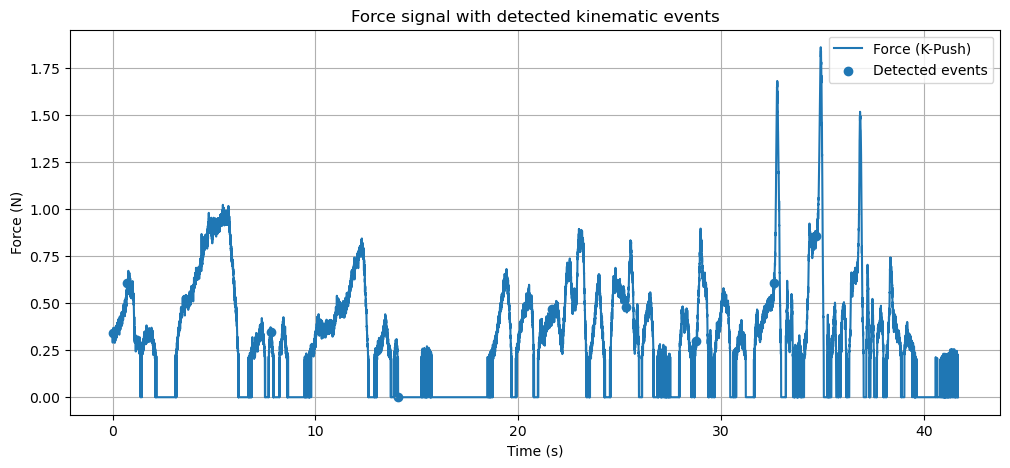

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Force signal
plt.plot(df_push["time"], df_push["force"], label="Force (K-Push)")

# Events
plt.scatter(df_events["time_max"], df_events["force_at_max"],
            label="Detected events", marker='o')

plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title("Force signal with detected kinematic events")
plt.legend()
plt.grid(True)
plt.show()

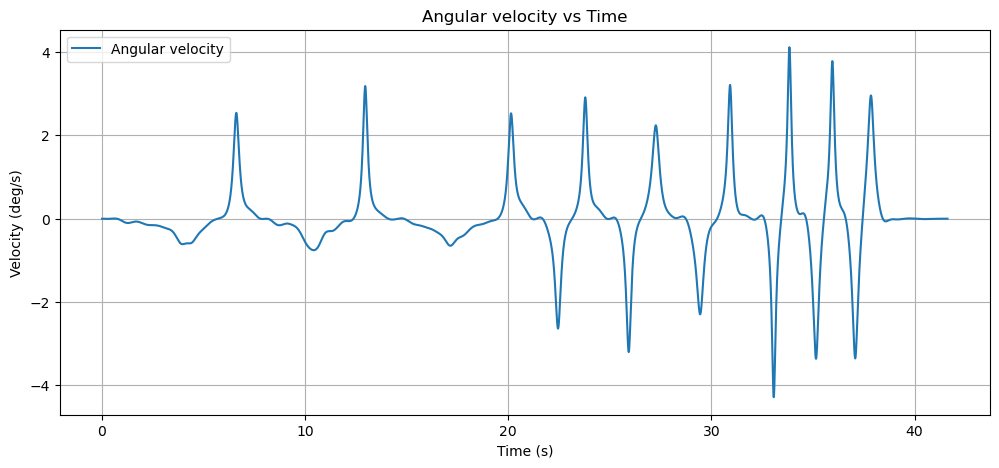

In [175]:
# ---------- ANGULAR VELOCITY ----------
dt = 1/125 # sampling interval in seconds (125 Hz)
angle = df_wrist_angles["angle_x_relative"].values 

angular_velocity=np.diff(angle)


#angular_velocity = np.gradient(angle, dt)

#df_wrist_angles["angular_velocity"] = angular_velocity

# Plot
plt.figure(figsize=(12,5))
plt.plot(df_wrist_angles["time"][:-1], angular_velocity,
#plt.plot(df_wrist_angles["time"], angular_velocity,
         label="Angular velocity")

plt.xlabel("Time (s)")
plt.ylabel("Velocity (deg/s)")
plt.title("Angular velocity vs Time")
plt.legend()
plt.grid(True)
plt.show()